## EDA - screen_time_mental_health

EDA för att inspektera datan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

In [7]:
Dataset_orginal = pd.read_csv(r'../backend/screen_time_mental_health.csv')

Dataset_orginal.info()

<class 'pandas.DataFrame'>
RangeIndex: 4810 entries, 0 to 4809
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   subject_id                4810 non-null   int64  
 1   sex                       4810 non-null   str    
 2   screen_time_index         4810 non-null   float64
 3   est_leisure_screen_hours  4810 non-null   float64
 4   sleep_quality_index       4810 non-null   float64
 5   avg_sleep_hours           4810 non-null   float64
 6   midsleep_weekend_hours    4810 non-null   float64
 7   social_jetlag_hours       4810 non-null   float64
 8   bdi_total                 4810 non-null   int64  
 9   depressed                 4810 non-null   int64  
dtypes: float64(6), int64(3), str(1)
memory usage: 375.9 KB


In [8]:
Dataset_orginal.head()

,subject_id,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
0,1,Boy,3.333,4.64,2.25,8.36,4.58,1.92,6,0
1,2,Girl,3.333,4.07,2.50,7.31,5.42,2.25,7,0
2,3,Boy,3.333,4.07,2.00,8.75,5.50,2.62,27,1
3,4,Boy,4.333,6.07,1.50,8.17,6.62,3.96,22,1
4,5,Boy,1.667,0.50,2.50,8.88,4.12,1.79,3,0


In [9]:
Dataset_orginal['sex'].value_counts()

sex
Boy     2446
Girl    2364
Name: count, dtype: int64

Det finns inte några saknande värde, alla kolumner har 4810 non null. `subject_id` är bara ordnings nummer och tas bort. `sex` är kategorisk och kodas med one-hot-endcoding.

In [10]:
Dataset = Dataset_orginal.drop(columns = ['subject_id'])
Dataset = pd.get_dummies(Dataset, columns=['sex'], dtype = int, prefix = 'dmy')

Dataset.head()

,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed,dmy_Boy,dmy_Girl
0,3.333,4.64,2.25,8.36,4.58,1.92,6,0,1,0
1,3.333,4.07,2.50,7.31,5.42,2.25,7,0,0,1
2,3.333,4.07,2.00,8.75,5.50,2.62,27,1,1,0
3,4.333,6.07,1.50,8.17,6.62,3.96,22,1,1,0
4,1.667,0.50,2.50,8.88,4.12,1.79,3,0,1,0


## Träningsdata, valideringsdata och testdata

Testdatan läggs undan redan nu och rörs inte tills modellen ska utväderas

In [11]:
train_full, test = train_test_split(Dataset, test_size = 0.2, random_state = 42)
train, val = train_test_split(train_full, test_size = 0.25, random_state = 42)

train.info()

<class 'pandas.DataFrame'>
Index: 2886 entries, 767 to 3086
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   screen_time_index         2886 non-null   float64
 1   est_leisure_screen_hours  2886 non-null   float64
 2   sleep_quality_index       2886 non-null   float64
 3   avg_sleep_hours           2886 non-null   float64
 4   midsleep_weekend_hours    2886 non-null   float64
 5   social_jetlag_hours       2886 non-null   float64
 6   bdi_total                 2886 non-null   int64  
 7   depressed                 2886 non-null   int64  
 8   dmy_Boy                   2886 non-null   int64  
 9   dmy_Girl                  2886 non-null   int64  
dtypes: float64(6), int64(4)
memory usage: 248.0 KB


In [12]:
corr_matrix = train.corr()
corr_matrix["bdi_total"].sort_values(ascending = False)

bdi_total                   1.000000
depressed                   0.812445
sleep_quality_index         0.377254
dmy_Girl                    0.275431
midsleep_weekend_hours      0.135853
screen_time_index           0.132316
est_leisure_screen_hours    0.109552
social_jetlag_hours         0.068935
avg_sleep_hours            -0.236312
dmy_Boy                    -0.275431
Name: bdi_total, dtype: float64

`sleep_quality_index` korrelerar starkast med `bdi_total` (positivt: högre index = sämre sömn), följt av `avg_sleep_hours` (negativt: mer sömn, färre symtom) och `dmy_Girl` (flickor har fler symtom). Skärmtidsvariablerna korrelerar svagt. Korrelationen mellan `depressed` och `bdi_total` beror på att `depressed` är definierad som `bdi_total >= 14`.

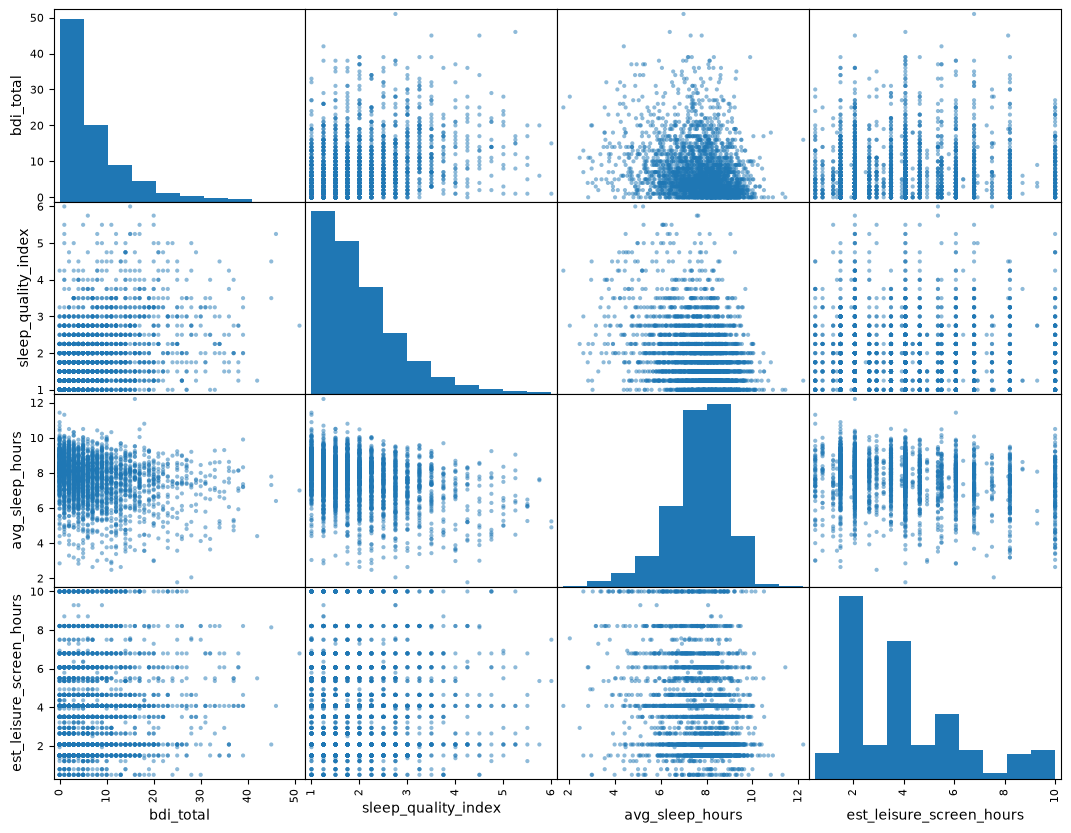

In [13]:
attributes = ["bdi_total", "sleep_quality_index", "avg_sleep_hours", "est_leisure_screen_hours"]
pd.plotting.scatter_matrix(train[attributes], figsize = (13, 10))
plt.show()